# Sovereign LHS — Inspect One Patient's FHIR (R)

**Phase 2 · companion to the OMOP explorer.** The pipeline keeps *two* views of every
synthetic Salvadoran patient:

```
FHIR R4 bundle  ── clinical / AI fidelity (this notebook)
      │  exporter.csv → ETL
      ▼
OMOP CDM v5.4   ── the OHDSI causal toolchain (sv_omop_explorer.ipynb)
```

Here we open **one raw FHIR R4 bundle** and walk its clinical content — demographics,
problem list, medications, encounters, and lab trajectories — the way an EHR would
hand it to you. This is the *same patient* that appears as **`person_id = 21`** in the
OMOP explorer (Cyndy Ji Monahan), so you can see both sides of the ETL.

> ⚠️ **Synthetic ≠ evidence.** Generated data, zero PHI. For building, teaching, and
> estimator validation only.

## 1 · Setup

FHIR bundles are JSON, so we parse with **`jsonlite`** and shape with base R +
`ggplot2`. All fast to install on Colab's R runtime.

In [1]:
pkgs <- c("jsonlite", "ggplot2")
new  <- pkgs[!vapply(pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(new)) install.packages(new, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({ library(jsonlite); library(ggplot2) })
theme_set(theme_minimal(base_size = 13))

`%||%` <- function(a, b) if (is.null(a) || length(a) == 0) b else a   # null-coalesce
cat("ready\n")

ready


## 2 · Get the bundle

The sample is one Synthea FHIR R4 bundle, curated to its clinically meaningful
resources (demographics, encounters, conditions, medications, immunizations, and the
lab/vital observations) so it stays small enough to pass around (~6 MB).

**To run on Colab**, host `sample_patient_fhir.json` somewhere reachable and paste the
URL below. Locally it just finds the file next to the notebook.

In [2]:
# ── DATA SOURCE ───────────────────────────────────────────────────────────
DATA_URL <- "https://github.com/rcurrie/sov-hlth-prot/raw/main/FHIR/sample_patient_fhir.json"

fhir_path <- Sys.getenv("SV_FHIR_FILE", "sample_patient_fhir.json")
url <- if (nzchar(Sys.getenv("SV_FHIR_URL"))) Sys.getenv("SV_FHIR_URL") else DATA_URL
if (!file.exists(fhir_path)) {
  for (p in c("FHIR/sample_patient_fhir.json", "../FHIR/sample_patient_fhir.json",
              "sample_patient_fhir.json", "notebooks/sample_patient_fhir.json")) {
    if (file.exists(p)) { fhir_path <- p; break }
  }
}
if (!file.exists(fhir_path) && nzchar(url)) {
  message("downloading bundle from ", url); download.file(url, (fhir_path <- "sample_patient_fhir.json"), mode = "wb")
}
stopifnot("sample_patient_fhir.json not found — set SV_FHIR_URL or place the file next to the notebook" =
          file.exists(fhir_path))

bundle    <- jsonlite::read_json(fhir_path, simplifyVector = FALSE)
resources <- lapply(bundle$entry, function(e) e$resource)
types     <- vapply(resources, function(r) r$resourceType %||% NA_character_, character(1))
cat("bundle:", bundle$resourceType, "· resources:", length(resources), "\n")

bundle: Bundle · resources: 6113 


## 3 · What's in the bundle?

A FHIR **Bundle** is a bag of typed **resources**. Here's the census — this is the raw
clinical footprint of one 60-year synthetic lifetime.

In [3]:
tab <- sort(table(types), decreasing = TRUE)
knitr::kable(data.frame(resource = names(tab), count = as.integer(tab)),
             caption = "FHIR resource types in the bundle")



Table: FHIR resource types in the bundle

|resource          | count|
|:-----------------|-----:|
|Observation       |  3304|
|MedicationRequest |  1454|
|Encounter         |   759|
|Condition         |   517|
|Immunization      |    65|
|CarePlan          |    13|
|Patient           |     1|

## 4 · Who is the patient?

The **`Patient`** resource carries demographics. Note the El Salvador address and
birthplace — the persona spine is Salvadoran.

In [4]:
pat <- resources[[ which(types == "Patient")[1] ]]

nm   <- pat$name[[1]]
name <- paste(paste(unlist(nm$given), collapse = " "), nm$family)
addr <- pat$address[[1]]
birthplace <- NULL
for (ext in pat$extension %||% list()) if (grepl("birthPlace", ext$url %||% "")) birthplace <- ext$valueAddress

profile <- data.frame(
  field = c("Name","Sex","Birth date","Age (2026)","Marital status",
            "Residence","Birthplace","Patient UUID"),
  value = c(name,
            pat$gender %||% NA,
            pat$birthDate %||% NA,
            2026L - as.integer(substr(pat$birthDate, 1, 4)),
            pat$maritalStatus$text %||% NA,
            paste(addr$city %||% "", addr$state %||% "", addr$country %||% "", sep = ", "),
            if (!is.null(birthplace)) paste(birthplace$city, birthplace$state, birthplace$country, sep=", ") else NA,
            pat$id %||% NA),
  stringsAsFactors = FALSE)
knitr::kable(profile, caption = "Patient profile (= OMOP person_id 21)")



Table: Patient profile (= OMOP person_id 21)

|field          |value                                |
|:--------------|:------------------------------------|
|Name           |Cyndy Ji Monahan                     |
|Sex            |female                               |
|Birth date     |1966-11-20                           |
|Age (2026)     |60                                   |
|Marital status |Married                              |
|Residence      |San Salvador Centro, El Salvador, SV |
|Birthplace     |San Miguel Norte, El Salvador, SV    |
|Patient UUID   |0aaa16f5-668d-343d-360f-cf9582d9d0fd |

## 5 · Problem list — Conditions

Each **`Condition`** carries a **SNOMED CT** code and an onset date. This is exactly
what the ETL lands in `condition_occurrence.condition_source_value` on the OMOP side.

In [5]:
ci <- which(types == "Condition")
conds <- do.call(rbind, lapply(resources[ci], function(r) {
  cd <- r$code$coding[[1]]
  data.frame(onset     = substr(r$onsetDateTime %||% NA, 1, 10),
             snomed    = cd$code %||% NA,
             condition = cd$display %||% NA,
             stringsAsFactors = FALSE)
}))
conds <- conds[order(conds$onset), ]
cat(nrow(conds), "condition records ·", length(unique(conds$snomed)), "distinct codes\n\n")
# distinct conditions, earliest onset first
uniq <- conds[!duplicated(conds$snomed), ]
knitr::kable(head(uniq, 15), row.names = FALSE, caption = "Problem list (distinct SNOMED conditions, earliest onset)")

517 condition records · 65 distinct codes





Table: Problem list (distinct SNOMED conditions, earliest onset)

|onset      |snomed    |condition                                |
|:----------|:---------|:----------------------------------------|
|1966-11-20 |314529007 |Medication review due (situation)        |
|1968-02-14 |195662009 |Acute viral pharyngitis (disorder)       |
|1969-07-13 |444814009 |Viral sinusitis (disorder)               |
|1970-01-10 |125605004 |Fracture of bone (disorder)              |
|1970-01-10 |263102004 |Fracture subluxation of wrist (disorder) |
|1971-12-01 |384709000 |Sprain (morphologic abnormality)         |
|1971-12-01 |44465007  |Sprain of ankle (disorder)               |
|1974-11-18 |38362002  |Dengue                                   |
|1976-10-10 |66383009  |Gingivitis (disorder)                    |
|1976-10-17 |109570002 |Primary dental caries (disorder)         |
|1976-12-05 |18718003  |Gingival disease (disorder)              |
|1979-12-16 |160968000 |Risk activity involvement (finding)  

## 6 · Medications

**`MedicationRequest`** resources carry **RxNorm** codes → `drug_exposure` in OMOP.
We tally the distinct medications this patient was prescribed over their lifetime.

In [6]:
mi <- which(types == "MedicationRequest")
meds <- do.call(rbind, lapply(resources[mi], function(r) {
  cd <- r$medicationCodeableConcept$coding[[1]]
  data.frame(rxnorm = cd$code %||% NA, drug = cd$display %||% NA,
             authored = substr(r$authoredOn %||% NA, 1, 10), stringsAsFactors = FALSE)
}))
agg <- aggregate(authored ~ drug + rxnorm, meds,
                 FUN = function(x) sprintf("%d orders (from %s)", length(x), min(x)))
names(agg)[3] <- "history"
knitr::kable(agg[order(-as.integer(sub(" .*","",agg$history))), ], row.names = FALSE,
             caption = "Distinct medications (RxNorm)")



Table: Distinct medications (RxNorm)

|drug                                                                                                                           |rxnorm  |history                      |
|:------------------------------------------------------------------------------------------------------------------------------|:-------|:----------------------------|
|Hydrochlorothiazide 25 MG Oral Tablet                                                                                          |310798  |290 orders (from 2006-11-26) |
|lisinopril 10 MG Oral Tablet                                                                                                   |314076  |290 orders (from 2006-11-26) |
|insulin isophane, human 70 UNT/ML / insulin, regular, human 30 UNT/ML Injectable Suspension [Humulin]                          |106892  |286 orders (from 2009-03-22) |
|24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                                 

## 7 · Encounters over time

**`Encounter`** resources are the visit backbone → `visit_occurrence`. Here's the
yearly encounter count across the patient's life.

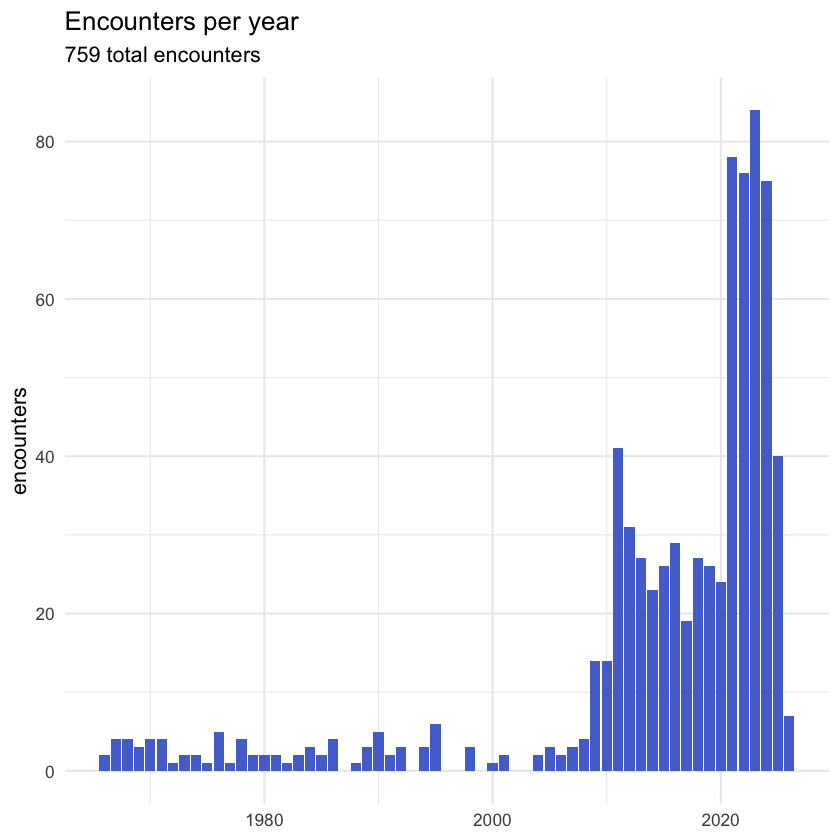

In [7]:
ei <- which(types == "Encounter")
enc <- do.call(rbind, lapply(resources[ei], function(r) {
  data.frame(year = as.integer(substr(r$period$start %||% NA, 1, 4)),
             kind = (r$type[[1]]$text %||% (r$class$code %||% NA)), stringsAsFactors = FALSE)
}))
per_year <- as.data.frame(table(year = enc$year))
per_year$year <- as.integer(as.character(per_year$year))
ggplot(per_year, aes(year, Freq)) +
  geom_col(fill = "#5472d3") +
  labs(title = "Encounters per year", subtitle = paste(nrow(enc), "total encounters"),
       x = NULL, y = "encounters")

## 8 · Lab trajectories

**`Observation`** resources hold the labs/vitals (**LOINC**) → `measurement` in OMOP.
We reconstruct this patient's **HbA1c** (glycemic control) and **eGFR** (kidney
function) over time — the same longitudinal signal the OMOP notebook plots, here
straight from raw FHIR.

HbA1c: 289  eGFR: 477 readings


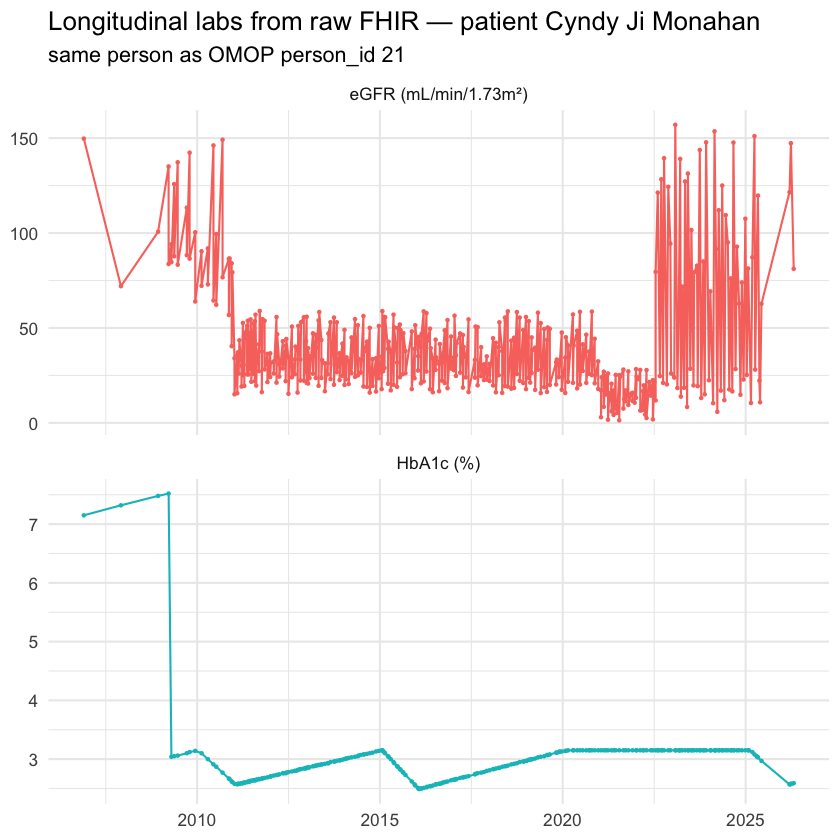

In [8]:
oi <- which(types == "Observation")
want <- c("4548-4" = "HbA1c (%)", "33914-3" = "eGFR (mL/min/1.73m²)")
labs <- do.call(rbind, lapply(resources[oi], function(r) {
  cd <- r$code$coding[[1]]; code <- cd$code %||% NA
  if (is.null(r$valueQuantity) || !(code %in% names(want))) return(NULL)
  data.frame(date = as.Date(substr(r$effectiveDateTime %||% NA, 1, 10)),
             lab  = want[[code]], value = r$valueQuantity$value %||% NA,
             stringsAsFactors = FALSE)
}))
cat("HbA1c:", sum(labs$lab == "HbA1c (%)"),
    " eGFR:", sum(labs$lab != "HbA1c (%)"), "readings\n")

ggplot(labs, aes(date, value, colour = lab)) +
  geom_line() + geom_point(size = 0.5) +
  facet_wrap(~lab, scales = "free_y", ncol = 1) + guides(colour = "none") +
  labs(title = "Longitudinal labs from raw FHIR — patient Cyndy Ji Monahan",
       subtitle = "same person as OMOP person_id 21", x = NULL, y = NULL)

## 9 · FHIR → OMOP: the two views line up

What you just inspected is the **source** the ETL consumes. The mapping is direct:

| FHIR resource | → OMOP table | code system → (standard) |
|---|---|---|
| `Patient` | `person` | — |
| `Encounter` | `visit_occurrence` | — |
| `Condition` | `condition_occurrence` | SNOMED → SNOMED |
| `MedicationRequest` | `drug_exposure` | RxNorm → RxNorm |
| `Observation` | `measurement` | LOINC → LOINC |

The same patient is `person_id = 21` in [`sv_omop_explorer.ipynb`](sv_omop_explorer.ipynb) —
the HbA1c/eGFR curves match. FHIR is the **clinical/AI-fidelity** feed (rich, nested,
great for LLM work); OMOP is the **flattened, standardized** feed the OHDSI causal
toolchain runs on. The one piece still ahead is **vocabulary mapping** — turning those
source codes into OMOP *standard concept_ids* (deferred; needed when the real ICD-11
feed arrives).